In [1]:
import sys
import os
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from starcat import BuildConsensusReference, starCAT

/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/minicon

In [2]:
# 1. 读取数据
adata = sc.read_h5ad(
    "/sibcb1/bioinformatics/yangyue/project/241120_TFs/data/COVID_GSE145926_allcell.h5ad"
)

# 2. 只保留 NK 细胞
query_adata = adata[adata.obs['celltype'] == 'NK'].copy()
query_adata

AnnData object with n_obs × n_vars = 1081 × 23916
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'ID', 'sample', 'sample_new', 'group', 'group1', 'disease', 'nCoV_mean', 'nFeature_RNA_low', 'nFeature_RNA_high', 'before', 'filter', 'integrated_snn_res.1.2', 'seurat_clusters', 'idt', 'hasnCoV', 'cluster', 'celltype', 'barcode'
    obsm: 'X_pca', 'X_tsne', 'X_umap'

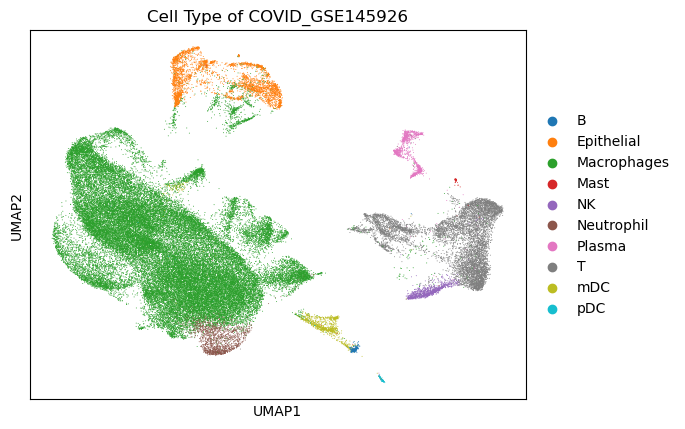

In [3]:
sc.pl.umap(adata, color='celltype', title='Cell Type of COVID_GSE145926')

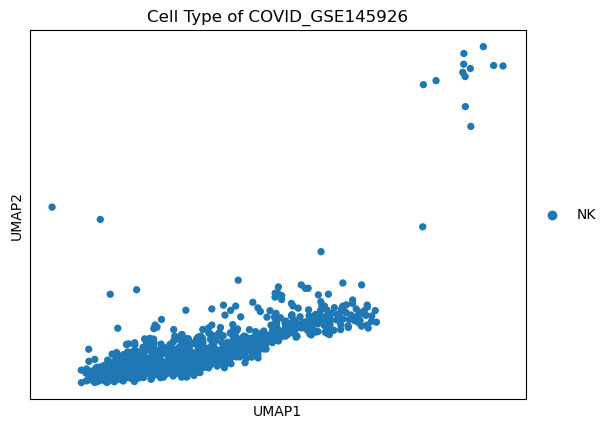

In [4]:
query_adata
sc.pl.umap(query_adata, color='celltype', title='Cell Type of COVID_GSE145926')

In [5]:
#group: healthy controls (HC) \moderate (M) \ severe (S)
query_adata.obs['group'].value_counts()

S     686
M     298
HC     97
Name: group, dtype: int64

In [6]:
# 查看 group 列包含的所有类别
print(query_adata.obs['group'].unique().tolist())
# 1. 定义您想挑出的组名列表
target_groups = ['HC', 'M', 'S']  # 请根据第一步的输出结果修改这里！

# 2. 提取子集并生成一个新的 AnnData 对象
# 注意结尾加上 .copy()，避免修改子集时影响原数据
control_adata = query_adata[query_adata.obs['group'].isin(target_groups)].copy()

# 3. 查看提取后的结果
print(f"提取完成！剩余细胞数: {control_adata.n_obs}")
print("包含的组别:", control_adata.obs['group'].unique().tolist())
# 假设您的病人/样本 ID 存在 'sample' 列中 
# （如果实际存在 'ID' 或 'orig.ident' 列，请将下方的 'sample' 替换掉）

# ==========================================
# 1. 查看对照组中【总共】有几个不同的病人
# ==========================================
num_control_patients = control_adata.obs['sample'].nunique()
print(f"✅ 对照组中总共有 {num_control_patients} 个不重复的病人/样本。")

# ==========================================
# 2. 查看具体的【病人 ID 列表】
# ==========================================
control_patient_ids = control_adata.obs['sample'].unique().tolist()
print(f"🔍 对照组的病人 ID 列表: {control_patient_ids}")

# ==========================================
# 3. 进阶：查看【每个具体分组】下分别有几个病人
# ==========================================
# 比如看看 'Healthy' 里有几个，'Control' 里有几个
patients_per_group = control_adata.obs.groupby('group')['sample'].nunique()
print("\n📊 各个对照分组的病人数量统计：")
print(patients_per_group)

['HC', 'M', 'S']
提取完成！剩余细胞数: 1081
包含的组别: ['HC', 'M', 'S']
✅ 对照组中总共有 13 个不重复的病人/样本。
🔍 对照组的病人 ID 列表: ['C51', 'C52', 'C100', 'GSM3660650', 'C141', 'C142', 'C144', 'C143', 'C145', 'C146', 'C148', 'C149', 'C152']

📊 各个对照分组的病人数量统计：
group
HC    4
M     3
S     6
Name: sample, dtype: int64


In [7]:

custom_tcat = starCAT(reference='/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.3.cNMF_NK/Example_refbuilder_NK/starcat_refstarcat_consensus_spectra_normalized.filtered.txt')

usage, _ = custom_tcat.fit_transform(query_adata)


Using user specified reference spectra file /sibcb1/bioinformatics/yangyue/project/immunotherapy/7.3.cNMF_NK/Example_refbuilder_NK/starcat_refstarcat_consensus_spectra_normalized.filtered.txt
No scores provided
5311 out of 5311 genes in the reference overlap with the query


In [8]:
#usage.to_csv("/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.3.cNMF_NK/5.disease/5.1.COVID/5.1.NK_COVID_GSE145926_cGEP_usage_cell_level.csv")


In [9]:
# 加上cGEP对应的注释
gep_anno = pd.read_csv("/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.3.cNMF_NK/3.3.NK_cGEP_ALL_ANNO/3.3.NK_cGEP_Anno_Complete_With_Genes_final.csv")
# 去掉 Class 为 Artifact 或 Doublet  的行
gep_anno_filt = gep_anno[~gep_anno["Category"].isin(["Artifact", "Doublet"])]
gep_anno_filt

,cGEP_Cluster,cGEP_Anno_Name,Category,cGEP_signature
1,cGEP2,TaNK_Cytoskeleton_Stress,Functional,"PFN1,ACTB,FCER1G,IFITM1,TMSB10,MYL12A,NKG7,SER..."
2,cGEP3,Translational_Activity,Functional,"EEF1A1,RPL13,RPL3,RPL32,RPL34,RPL10,RPL23A,RPL..."
3,cGEP4,TaNK_HSP_Stress,Functional,"DNAJB1,BAG3,CACYBP,ZFAND2A,COL21A1,DNAJA1,SERP..."
4,cGEP5,NK_Activation_IEG,Functional,"ZFP36,BTG2,NR4A2,JUNB,NR4A1,CD69,TNFAIP3,CXCR4..."
5,cGEP6,Acute_Inflammatory,Functional,"IGFBP1,ITIH3,MT-ND4,MT-CO3,MT-CO2,MT-CYB,MT-AT..."
6,cGEP7,trNK_Quiescence,Lineage,"BTG1,ITM2C,RPL13A,KRT81,CAPG,GZMK,RPL27A,KRT86..."
7,cGEP8,CD56bright_Translation,Lineage,"RPL13,RPLP1,TPT1,IL7R,CCR6,RPL32,NCR2,RPL30,EE..."
8,cGEP9,CD56dim_Cytotoxic,Lineage,"NKG7,PRF1,SPON2,FGFBP2,GZMB,FCGR3A,SCGB1D2,B2M..."
9,cGEP10,NK_Cycling_G2M,Functional,"TYMS,STMN1,TUBA1B,UBE2C,SPC25,MKI67,AURKB,TK1,..."
13,cGEP14,NK_ISG_Response,Functional,"ISG15,IFIT3,IFI6,MX1,RSAD2,USP18,IFIT1,CMPK2,E..."


In [10]:
# 1. 找出 Artifact / Doublet  对应的 cGEP 名称
remove_geps = (
    gep_anno.loc[
        gep_anno["Category"].isin(["Artifact", "Doublet"]),
        "cGEP_Cluster"]
    .unique()
    .tolist()
)

print("需要去掉的 cGEP：", remove_geps)

# 2. 从 usage 表格中去掉这些 cGEP 列
usage = usage.drop(columns=remove_geps, errors="ignore")

usage

需要去掉的 cGEP： ['cGEP1', 'cGEP11', 'cGEP12', 'cGEP13', 'cGEP16', 'cGEP17', 'cGEP18', 'cGEP19', 'cGEP20', 'cGEP21', 'cGEP24', 'cGEP25', 'cGEP26', 'cGEP32', 'cGEP33', 'cGEP36', 'cGEP37', 'cGEP38', 'cGEP41']


,cGEP2,cGEP3,cGEP4,cGEP5,cGEP6,cGEP7,cGEP8,cGEP9,cGEP10,cGEP14,...,cGEP23,cGEP27,cGEP28,cGEP29,cGEP30,cGEP31,cGEP34,cGEP35,cGEP39,cGEP40
ACCGTAAAGGGATACC_1,0.008017,0.002366,0.026447,0.000122,0.000020,0.000084,0.020945,0.000294,0.000171,0.000168,...,0.074288,0.000154,0.000861,0.000424,0.001867,0.000527,0.003958,0.003910,0.000965,0.000074
ATGCGATTCGAATCCA_1,0.003361,0.000006,0.018346,0.000056,0.000317,0.017888,0.021720,0.002246,0.000002,0.000553,...,0.073414,0.000087,0.296130,0.002746,0.001557,0.000447,0.000043,0.005444,0.006748,0.000564
CTGGTCTTCAGATAAG_1,0.006657,0.002856,0.005850,0.000209,0.000059,0.006056,0.000667,0.000339,0.091607,0.001065,...,0.002715,0.004325,0.012396,0.008881,0.000925,0.004131,0.001783,0.000019,0.001280,0.003504
CTGTTTATCCGTTGTC_1,0.025739,0.000825,0.005542,0.000218,0.000085,0.092552,0.040278,0.000691,0.000376,0.002621,...,0.072695,0.001797,0.272638,0.004324,0.000225,0.004270,0.001285,0.014105,0.003838,0.003072
TACGGGCCAAAGTGCG_1,0.006889,0.000217,0.014727,0.000153,0.000145,0.017705,0.003780,0.000767,0.028058,0.001519,...,0.064656,0.001395,0.052079,0.008497,0.000389,0.021705,0.000644,0.013491,0.000494,0.000434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TAGAGCTTCGCACTCT_13,0.048001,0.075453,0.017523,0.008438,0.006386,0.042243,0.036886,0.018109,0.000950,0.001155,...,0.050395,0.001975,0.030053,0.002583,0.001832,0.006211,0.004030,0.023377,0.104467,0.006188
TATCAGGAGCCAGTTT_13,0.004353,0.003244,0.000322,0.001004,0.000951,0.001049,0.000122,0.001497,0.006882,0.000297,...,0.000295,0.000578,0.002598,0.071850,0.002962,0.000821,0.099887,0.000142,0.000228,0.020422
TATTACCTCTGCCCTA_13,0.021688,0.000282,0.000708,0.004555,0.034813,0.107841,0.025793,0.006310,0.000046,0.000335,...,0.003207,0.052268,0.212489,0.000665,0.000479,0.005887,0.010736,0.011595,0.035165,0.014319
TCACAAGGTTAAGGGC_13,0.041183,0.000298,0.006734,0.000496,0.000722,0.291495,0.094568,0.001876,0.000037,0.000139,...,0.007500,0.008704,0.132304,0.011816,0.000426,0.009701,0.025625,0.054469,0.089698,0.001309


In [11]:
# 1. 修正字典构建逻辑
# 去掉代码中的 "cGEP" 前缀，直接读取
anno_dict = {
    row['cGEP_Cluster']: f"{row['cGEP_Cluster']}_{row['cGEP_Anno_Name']}" 
    for index, row in gep_anno_filt.iterrows()
}

# 2. 再次检查映射字典
# 正确的样子应该是: [('cGEP1', 'cGEP1_Translation'), ...]
print("修正后的映射字典 (前3个):")
print(list(anno_dict.items())[:3])

# 3. 执行重命名
usage.rename(columns=anno_dict, inplace=True)

# 4. 验证结果
print("新的列名:")
print(usage.columns[:5])

修正后的映射字典 (前3个):
[('cGEP2', 'cGEP2_TaNK_Cytoskeleton_Stress'), ('cGEP3', 'cGEP3_Translational_Activity'), ('cGEP4', 'cGEP4_TaNK_HSP_Stress')]
新的列名:
Index(['cGEP2_TaNK_Cytoskeleton_Stress', 'cGEP3_Translational_Activity',
       'cGEP4_TaNK_HSP_Stress', 'cGEP5_NK_Activation_IEG',
       'cGEP6_Acute_Inflammatory'],
      dtype='object')


In [12]:
# ===========================
# 步骤 1: 准备数据到 obs 中
# ===========================
print("正在将 Usage 数据同步到 adata.obs...")

# 获取 usage 表格中所有的列名（即所有的 GEP 名字）
all_gep_names = usage.columns.tolist()

# 将这些数据赋值给 query_adata.obs
# 我们加一个统一的前缀 "Usage: "，这样在图的标题里看起来更清晰
plot_features_list = []
for col in all_gep_names:
    # 新名字例如："Usage: cGEP1_Translation"
    new_obs_name = f"Usage: {col}"
    query_adata.obs[new_obs_name] = usage[col].values
    plot_features_list.append(new_obs_name)

n_geps = len(plot_features_list)
print(f"准备就绪，共计 {n_geps} 个 GEP 将被绘制。")

正在将 Usage 数据同步到 adata.obs...
准备就绪，共计 22 个 GEP 将被绘制。


正在将 Usage 数据同步到 adata.obs...
准备就绪，共计 22 个 GEP 将被绘制。
开始绘制 UMAP，这可能需要一点时间...


/var/tmp/ipykernel_19973/46656631.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()



>>> 绘图完成！ <<<


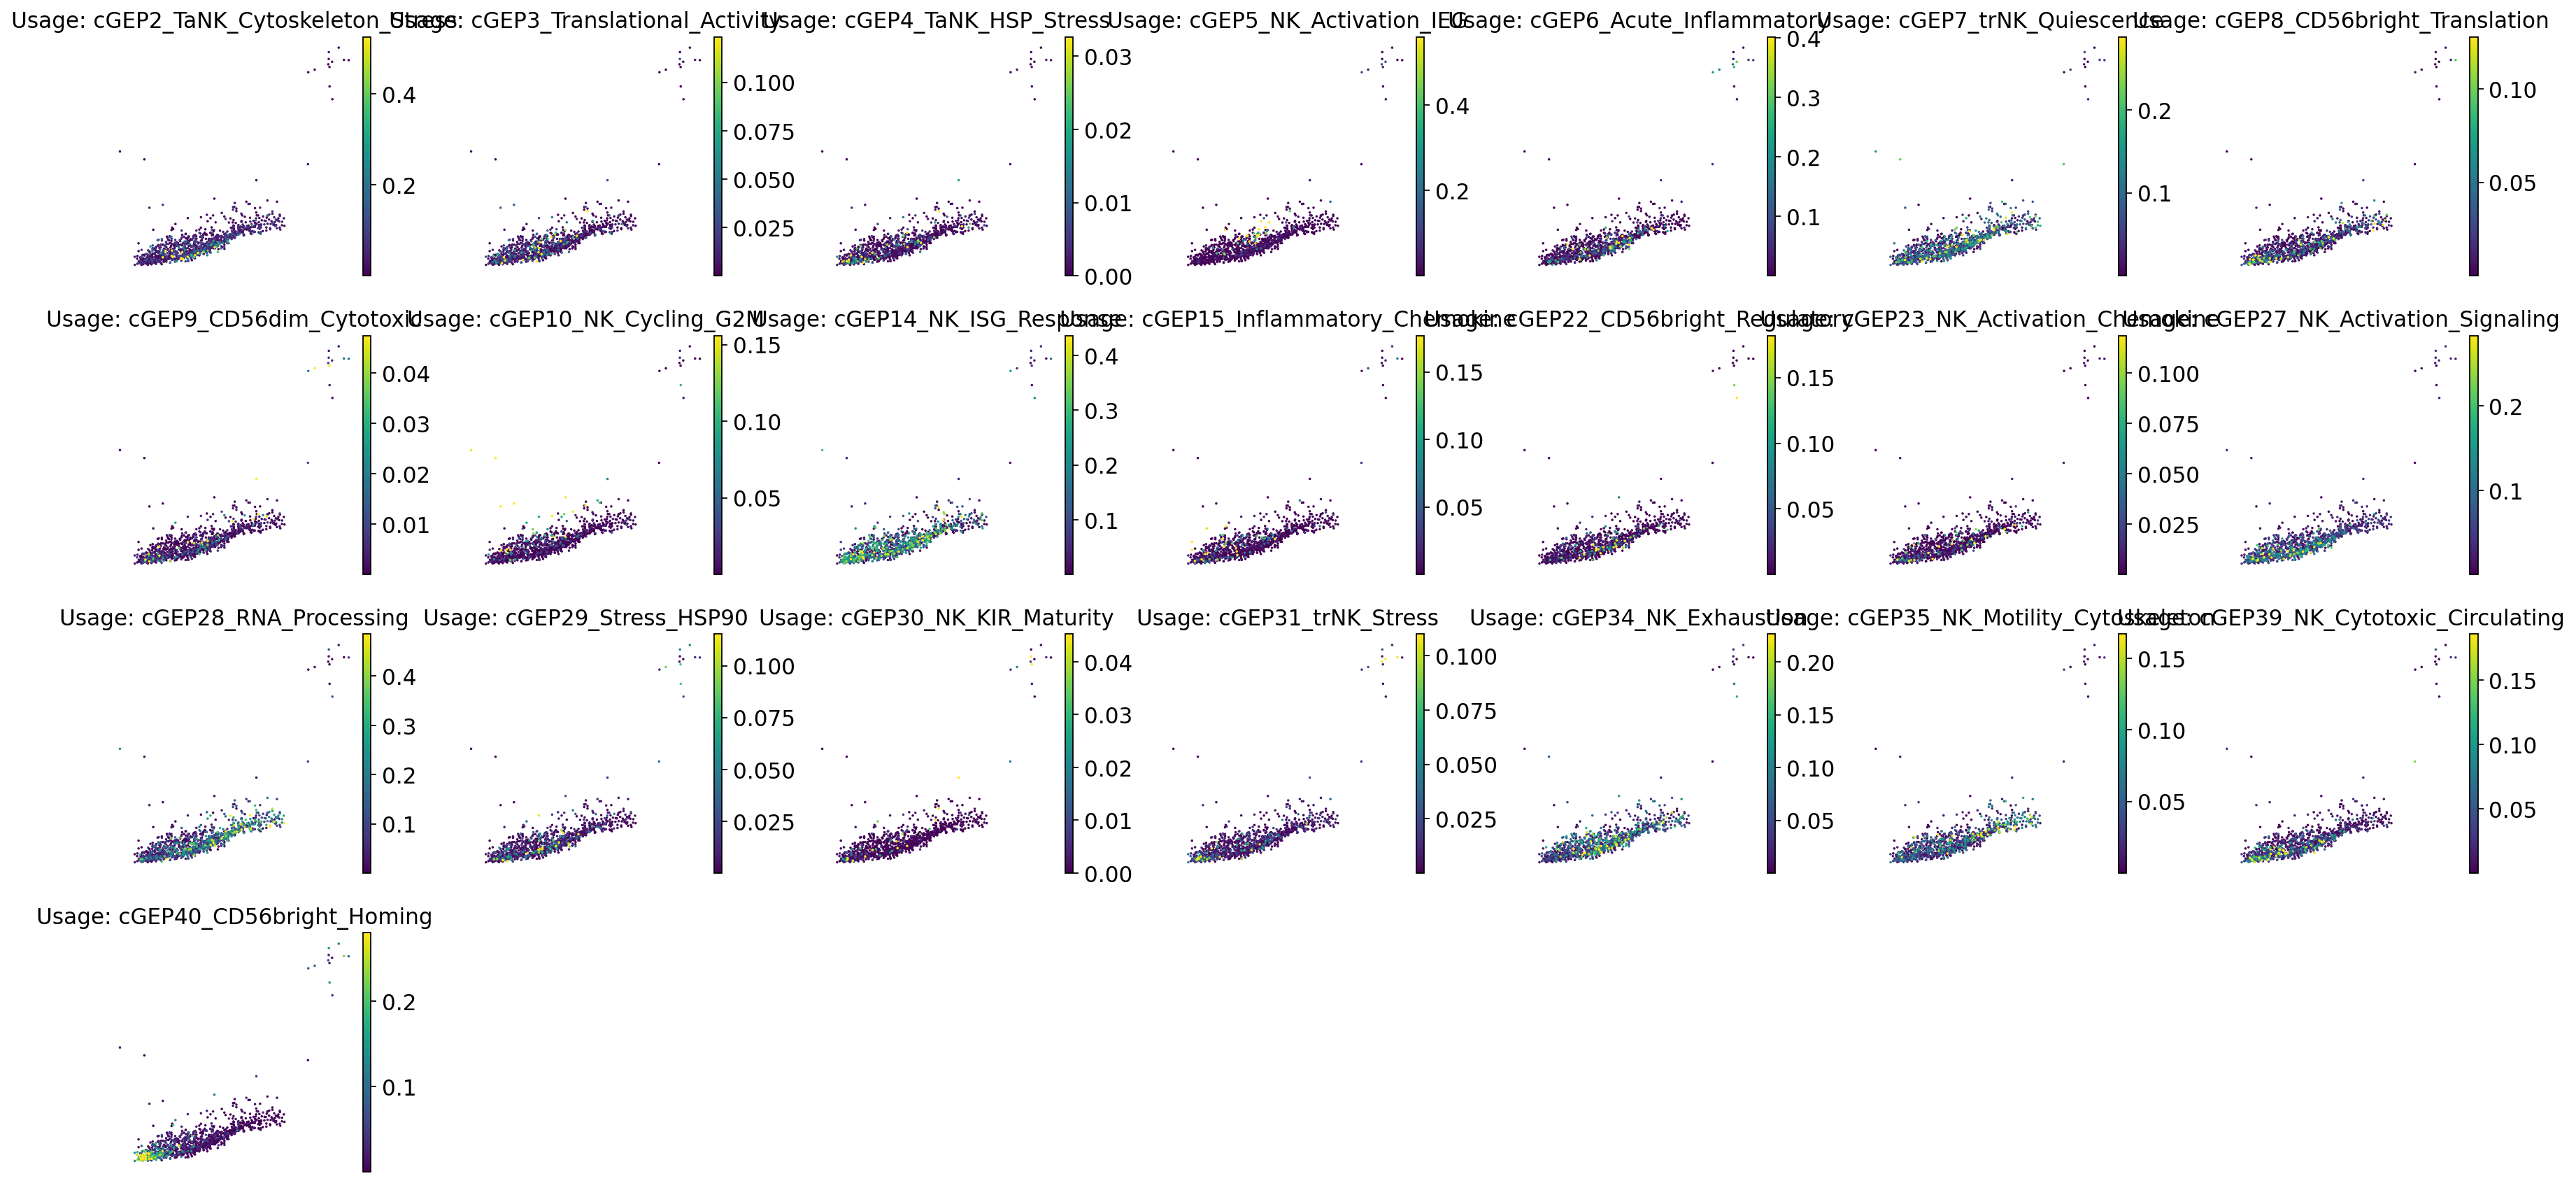

In [13]:
# ===========================
# 步骤 1: 准备数据到 obs 中
# ===========================
print("正在将 Usage 数据同步到 adata.obs...")

# 获取 usage 表格中所有的列名（即所有的 GEP 名字）
all_gep_names = usage.columns.tolist()

# 将这些数据赋值给 query_adata.obs
# 我们加一个统一的前缀 "Usage: "，这样在图的标题里看起来更清晰
plot_features_list = []
for col in all_gep_names:
    # 新名字例如："Usage: cGEP1_Translation"
    new_obs_name = f"Usage: {col}"
    query_adata.obs[new_obs_name] = usage[col].values
    plot_features_list.append(new_obs_name)

n_geps = len(plot_features_list)
print(f"准备就绪，共计 {n_geps} 个 GEP 将被绘制。")


# ===========================
# 步骤 2: 批量绘图并保存
# ===========================
print("开始绘制 UMAP，这可能需要一点时间...")

# 设置绘图参数
sc.set_figure_params(dpi_save=300, figsize=(3, 3)) # 设置每一张小图的尺寸和保存分辨率

plot = sc.pl.umap(
    query_adata,
    color=plot_features_list, # 传入包含所有名字的列表
    vmax='p99',        # 关键：切除前1%的极端值，否则图可能一片黑
    cmap='viridis',    # 配色方案：viridis(黄紫), plasma(黄蓝), Reds(红)
    ncols=7,           # 每行显示 7 张图 (根据总数调整，70个正好画10行)
    s=10,              # 点的大小
    frameon=False,     # 去掉外边框，更美观
    show=False,        # 关键：设置为 False，不直接在屏幕显示
    return_fig=True    # 返回图像对象以便保存
)
plot.show()
# 定义保存路径
output_filename = "./5.disease/5.1.COVID/5.NK_COVID_GEP_Usage_Visualization.png"

# 保存图片
# bbox_inches='tight' 可以去除多余白边
plot.savefig(output_filename, bbox_inches='tight')

print(f"\n>>> 绘图完成！ <<<")


In [14]:
query_adata

AnnData object with n_obs × n_vars = 1081 × 23916
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'ID', 'sample', 'sample_new', 'group', 'group1', 'disease', 'nCoV_mean', 'nFeature_RNA_low', 'nFeature_RNA_high', 'before', 'filter', 'integrated_snn_res.1.2', 'seurat_clusters', 'idt', 'hasnCoV', 'cluster', 'celltype', 'barcode', 'Usage: cGEP2_TaNK_Cytoskeleton_Stress', 'Usage: cGEP3_Translational_Activity', 'Usage: cGEP4_TaNK_HSP_Stress', 'Usage: cGEP5_NK_Activation_IEG', 'Usage: cGEP6_Acute_Inflammatory', 'Usage: cGEP7_trNK_Quiescence', 'Usage: cGEP8_CD56bright_Translation', 'Usage: cGEP9_CD56dim_Cytotoxic', 'Usage: cGEP10_NK_Cycling_G2M', 'Usage: cGEP14_NK_ISG_Response', 'Usage: cGEP15_Inflammatory_Chemokine', 'Usage: cGEP22_CD56bright_Regulatory', 'Usage: cGEP23_NK_Activation_Chemokine', 'Usage: cGEP27_NK_Activation_Signaling', 'Usage: cGEP28_RNA_Processing', 'Usage: cGEP29_Stress_HSP90', 'Usage: cGEP30_NK_KIR_Maturity', 'Usage: cGEP31_trNK_Stress', 'Usage: cGEP34

# 热图

图片已保存为: ./5.disease/5.1.COVID/5.COVID_NK_Usage_Heatmap_Right_Legend.png


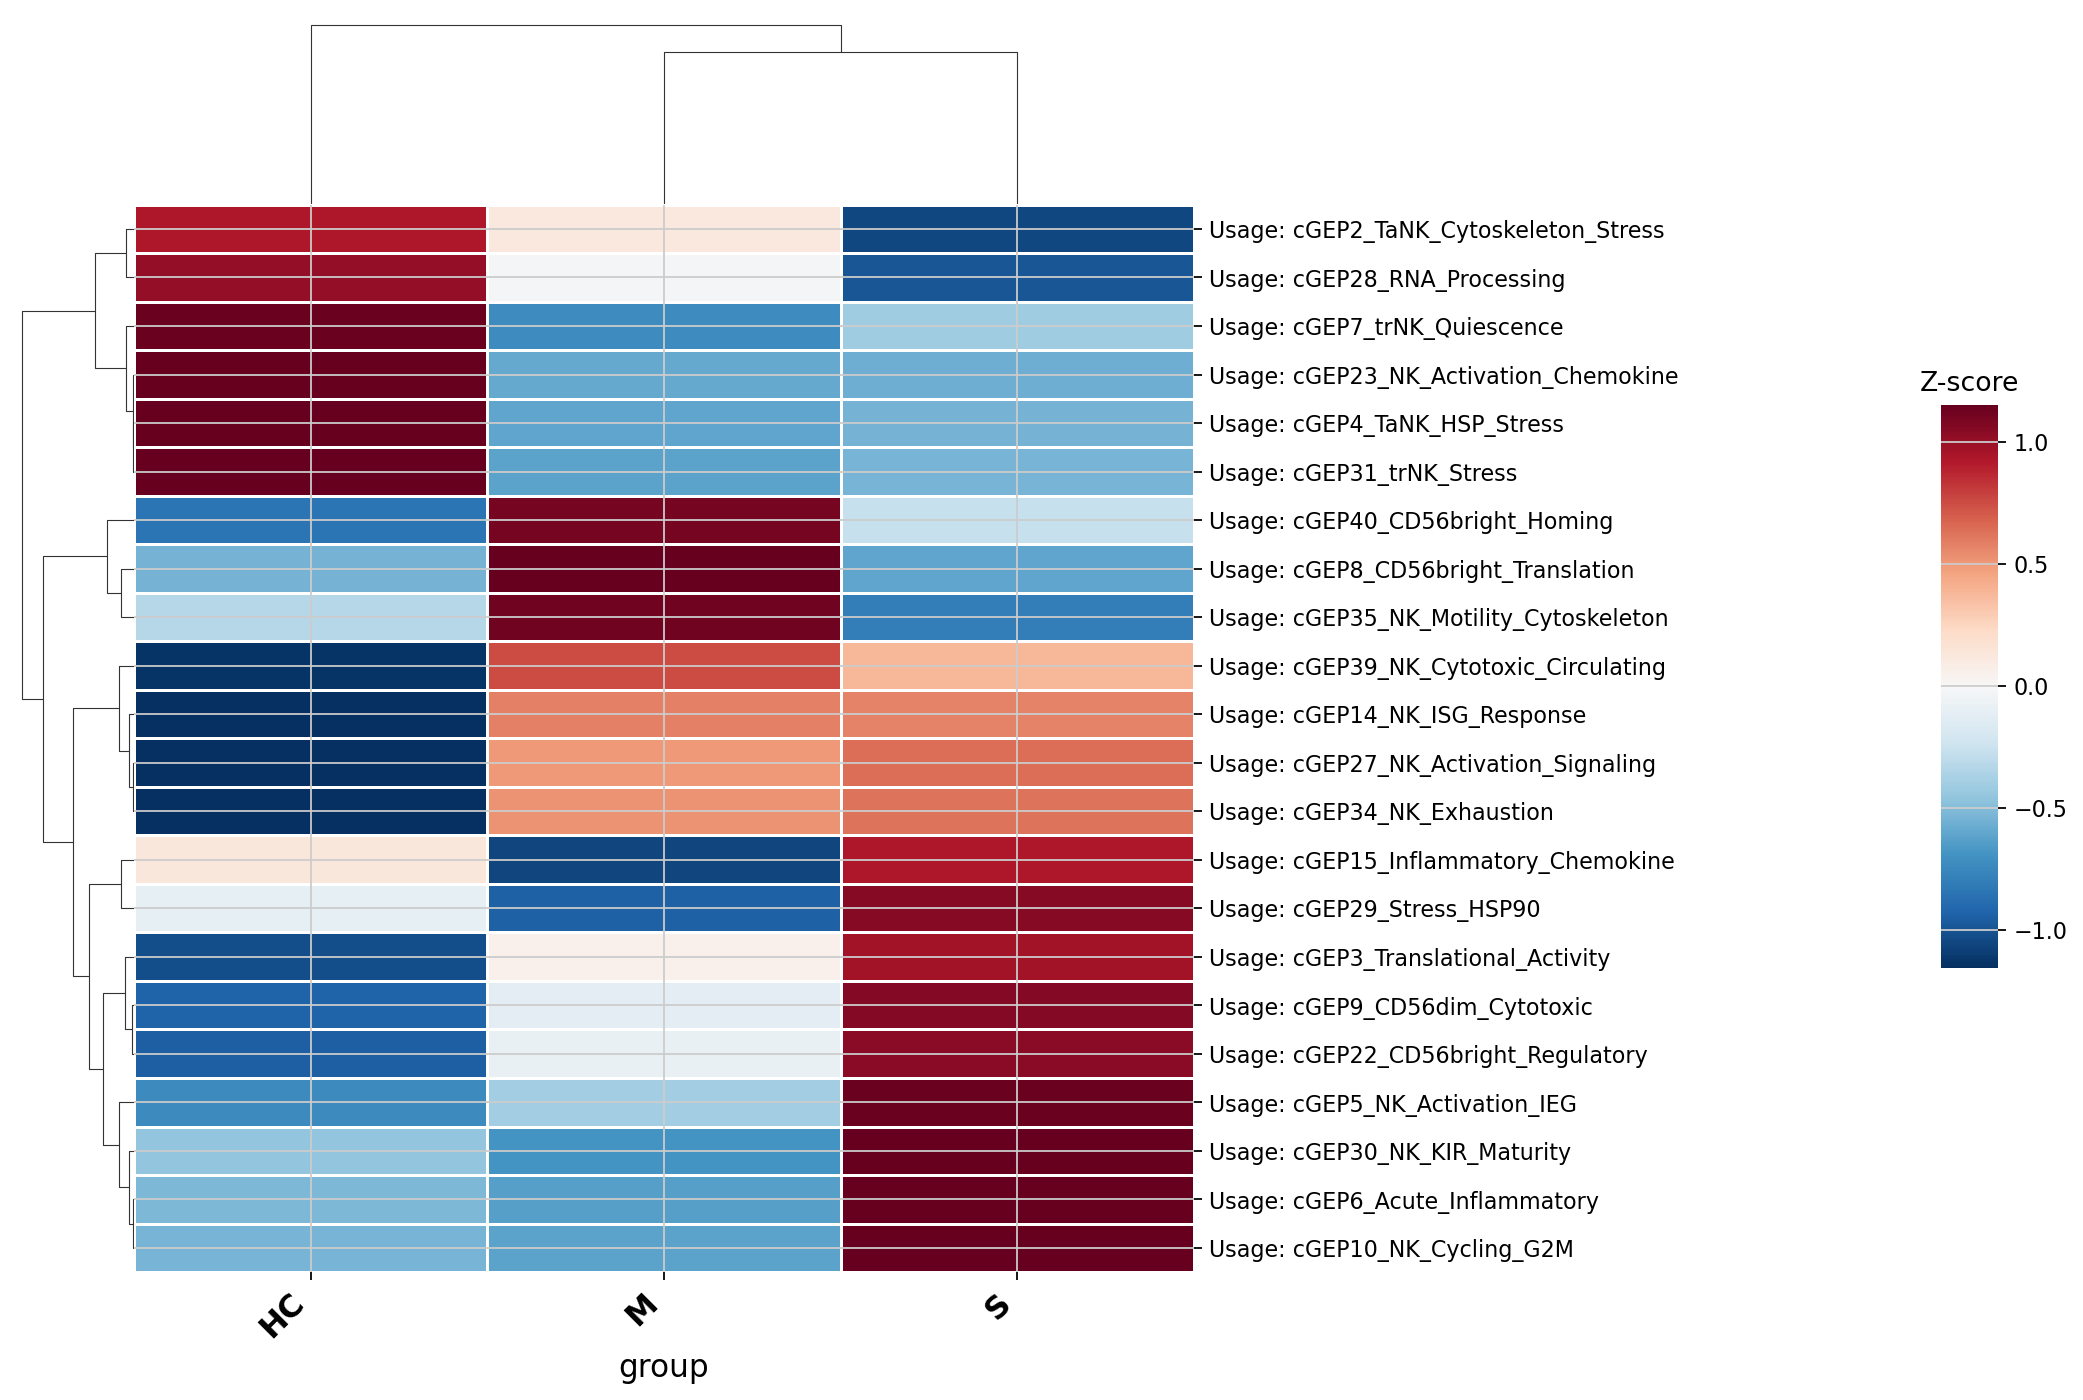

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 筛选数据 (保持不变)
usage_features = [col for col in query_adata.obs.columns if col.startswith('Usage:')]
df = query_adata.obs[usage_features + ['group']]
mean_usage = df.groupby('group').mean()

# 2. 绘制热图
g = sns.clustermap(
    mean_usage.T,
    z_score=0,
    cmap='RdBu_r',
    center=0,
    
    # 画布大小
    figsize=(12, len(usage_features) * 0.4),
    cbar_pos=(1.02, 0.3, 0.03, 0.4), 
    dendrogram_ratio=(0.1, 0.15),
    linewidths=0.5,
    linecolor='white',
    xticklabels=True,
    yticklabels=True
)

# 3. 调整字体和样式
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=14, fontweight='bold', rotation=45, ha='right')
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=10)

# 4. 优化右侧图例的标签
g.ax_cbar.set_title('Z-score', fontsize=12) # 给图例加标题
g.ax_cbar.tick_params(labelsize=10)         # 调整图例刻度字号

# 5. 保存 (bbox_inches='tight' 至关重要，否则右边的图例会被切掉)
output_filename = "./5.disease/5.1.COVID/5.COVID_NK_Usage_Heatmap_Right_Legend.png"
g.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"图片已保存为: {output_filename}")

plt.show()

# 火山图

In [16]:
# 1. 定义映射关系
# 这里的逻辑是：HC -> Healthy, S和M -> COVID
mapping = {
    'HC': 'Healthy',
    'M':  'COVID',
    'S':  'COVID'
}

# 2. 创建新列 'condition'
# 使用 map 函数自动转换
query_adata.obs['group2_condition'] = query_adata.obs['group'].map(mapping)

# 3. 检查一下结果
print("分组统计:")
print(query_adata.obs['group2_condition'].value_counts())

# 检查前几行，确保没填错
print("\n数据预览:")
print(query_adata.obs[['group', 'group2_condition']].head())

分组统计:
COVID      984
Healthy     97
Name: group2_condition, dtype: int64

数据预览:
                   group group2_condition
ACCGTAAAGGGATACC_1    HC          Healthy
ATGCGATTCGAATCCA_1    HC          Healthy
CTGGTCTTCAGATAAG_1    HC          Healthy
CTGTTTATCCGTTGTC_1    HC          Healthy
TACGGGCCAAAGTGCG_1    HC          Healthy


In [17]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 准备数据 ---
# 提取以 "Usage:" 开头的 GEP 列
usage_cols = [c for c in query_adata.obs.columns if c.startswith('Usage:')]
gep_data = query_adata.obs[usage_cols]

# 创建临时 AnnData 对象 (必须步骤，因为 scanpy 的统计工具只认 .X)
gep_adata = sc.AnnData(X=gep_data.values, obs=query_adata.obs)
gep_adata.var_names = usage_cols

# --- 2. 运行统计检验 ---
print("正在对比: COVID (All) vs Healthy...")

sc.tl.rank_genes_groups(
    gep_adata, 
    groupby='group2_condition',  # 【关键】使用您刚创建的新列
    groups=['COVID'],            # 实验组：COVID (包含 M 和 S)
    reference='Healthy',         # 对照组：Healthy (HC)
    method='wilcoxon'            # 秩和检验
)

# 提取结果
result = sc.get.rank_genes_groups_df(gep_adata, group='COVID')
df_volcano = result[['names', 'logfoldchanges', 'pvals_adj']].copy()
df_volcano.columns = ['GEP_Name', 'log2FC', 'padj']

# 清洗数据
df_volcano = df_volcano.replace([np.inf, -np.inf], np.nan).dropna()
print(f"分析完成，前 5 个差异最显著的 GEP:\n{df_volcano.head()}")

正在对比: COVID (All) vs Healthy...
分析完成，前 5 个差异最显著的 GEP:
                          GEP_Name    log2FC          padj
0    Usage: cGEP14_NK_ISG_Response  5.945051  2.386781e-45
1      Usage: cGEP34_NK_Exhaustion  2.915155  9.980295e-28
2   Usage: cGEP5_NK_Activation_IEG  3.997994  5.995480e-21
3  Usage: cGEP6_Acute_Inflammatory  1.520178  1.871694e-19
4  Usage: cGEP40_CD56bright_Homing  1.691129  2.114461e-08


正在对比: COVID (M+S) vs Healthy (HC)...
分析完成。前 5 个显著差异 GEP:
                          GEP_Name    log2FC          padj
0    Usage: cGEP14_NK_ISG_Response  5.945051  2.386781e-45
1      Usage: cGEP34_NK_Exhaustion  2.915155  9.980295e-28
2   Usage: cGEP5_NK_Activation_IEG  3.997994  5.995480e-21
3  Usage: cGEP6_Acute_Inflammatory  1.520178  1.871694e-19
4  Usage: cGEP40_CD56bright_Homing  1.691129  2.114461e-08
提示: 未安装 adjustText，标签可能会重叠。建议 pip install adjustText
图片已保存为: ./5.disease/5.1.COVID/5.1.NK_COVID_Volcano_COVID_Usage2.png


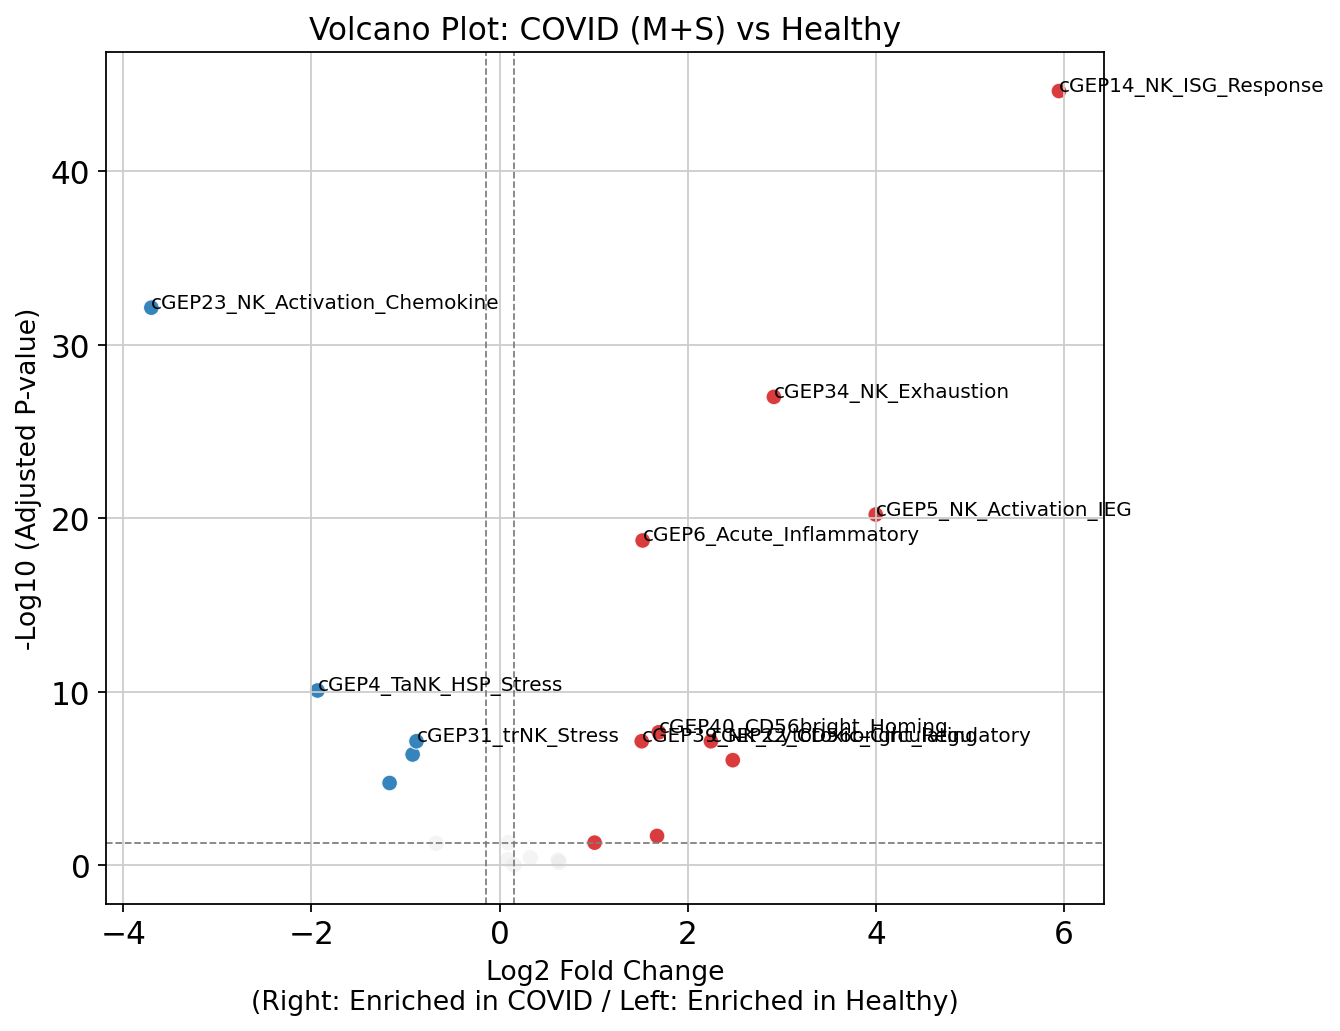

In [18]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from adjustText import adjust_text # 如果没有安装这个库，可以注释掉相关行

# ===========================
# 第一步：准备数据与差异分析
# ===========================

# 1. 提取所有 Usage 列
usage_cols = [c for c in query_adata.obs.columns if c.startswith('Usage:')]
gep_data = query_adata.obs[usage_cols]

# 2. 创建临时 AnnData 对象
# Scanpy 的 rank_genes_groups 只能针对 .X 矩阵计算，所以我们把 Usage 塞进去
gep_adata = sc.AnnData(X=gep_data.values, obs=query_adata.obs)
gep_adata.var_names = usage_cols

# 3. 运行差异分析 (Wilcoxon 秩和检验)
print("正在对比: COVID (M+S) vs Healthy (HC)...")
sc.tl.rank_genes_groups(
    gep_adata, 
    groupby='group2_condition',  # 使用您刚才创建的分组
    groups=['COVID'],            # 实验组：COVID
    reference='Healthy',         # 对照组：Healthy
    method='wilcoxon'
)

# 4. 提取结果表
result = sc.get.rank_genes_groups_df(gep_adata, group='COVID')
df_volcano = result[['names', 'logfoldchanges', 'pvals_adj']].copy()
df_volcano.columns = ['GEP_Name', 'log2FC', 'padj']

# 去除无效值
df_volcano = df_volcano.replace([np.inf, -np.inf], np.nan).dropna()
print("分析完成。前 5 个显著差异 GEP:")
print(df_volcano.head())

# ===========================
# 第二步：绘制火山图
# ===========================

# 1. 设置阈值 (Usage 数据是 0-1 的比例，变化幅度不如基因 Counts 大，建议调低 logFC 阈值)
pval_th = 0.05
logfc_th = 0.15  # 意味着 Usage 发生了约 1.1 倍的变化即可

# 2. 定义颜色
df_volcano['color'] = '#dddddd' # 默认灰色
df_volcano['alpha'] = 0.3       # 默认透明度

# 红色：显著上调 (COVID 特征)
up_mask = (df_volcano['padj'] < pval_th) & (df_volcano['log2FC'] > logfc_th)
df_volcano.loc[up_mask, 'color'] = '#D62728' # Red
df_volcano.loc[up_mask, 'alpha'] = 0.9

# 蓝色：显著下调 (Healthy 特征)
down_mask = (df_volcano['padj'] < pval_th) & (df_volcano['log2FC'] < -logfc_th)
df_volcano.loc[down_mask, 'color'] = '#1F77B4' # Blue
df_volcano.loc[down_mask, 'alpha'] = 0.9

# 3. 绘图
plt.figure(figsize=(8, 7))

# X轴: log2FC, Y轴: -log10(P值)
df_volcano['log_pval'] = -np.log10(df_volcano['padj'] + 1e-300) # 防止 log(0)

plt.scatter(
    df_volcano['log2FC'], 
    df_volcano['log_pval'], 
    c=df_volcano['color'], 
    s=50, 
    alpha=df_volcano['alpha'], 
    edgecolor='white', 
    linewidth=0.5
)

# 添加辅助线
plt.axvline(x=logfc_th, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(x=-logfc_th, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(y=-np.log10(pval_th), color='gray', linestyle='--', linewidth=0.8)

# 4. 标注显著的点 (Top 10)
texts = []
# 选取颜色不是灰色的点，按 P 值排序
sig_genes = df_volcano[df_volcano['color'] != '#dddddd'].sort_values('padj')
top_genes = sig_genes.head(10) # 标注前10个最显著的

for _, row in top_genes.iterrows():
    # 简化名字，去掉 "Usage: " 前缀
    simple_name = row['GEP_Name'].replace('Usage: ', '')
    texts.append(plt.text(row['log2FC'], row['log_pval'], simple_name, fontsize=9))

# 尝试自动调整文字位置 (防止重叠)
try:
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
except NameError:
    print("提示: 未安装 adjustText，标签可能会重叠。建议 pip install adjustText")

# 装饰图片
plt.title('Volcano Plot: COVID (M+S) vs Healthy', fontsize=14)
plt.xlabel(f'Log2 Fold Change\n(Right: Enriched in COVID / Left: Enriched in Healthy)', fontsize=12)
plt.ylabel('-Log10 (Adjusted P-value)', fontsize=12)

# 保存
output_file = "./5.disease/5.1.COVID/5.1.NK_COVID_Volcano_COVID_Usage2.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"图片已保存为: {output_file}")
plt.show()

正在对比: COVID (M+S) vs Healthy (HC)...
分析完成。前 5 个显著差异 GEP:
                          GEP_Name    log2FC          padj
0    Usage: cGEP14_NK_ISG_Response  5.945051  2.386781e-45
1      Usage: cGEP34_NK_Exhaustion  2.915155  9.980295e-28
2   Usage: cGEP5_NK_Activation_IEG  3.997994  5.995480e-21
3  Usage: cGEP6_Acute_Inflammatory  1.520178  1.871694e-19
4  Usage: cGEP40_CD56bright_Homing  1.691129  2.114461e-08

分析完成。以下是将在火山图上标注的极显著 cGEP：

--- 在 COVID 中最显著上调的 Top 5 cGEP (对应图右侧红点) ---
                      GEP_Name   log2FC         padj  log_pval
 Usage: cGEP14_NK_ISG_Response 5.945051 2.386781e-45 44.622187
   Usage: cGEP34_NK_Exhaustion 2.915155 9.980295e-28 27.000857
Usage: cGEP5_NK_Activation_IEG 3.997994 5.995480e-21 20.222176

--- 在 COVID 中最显著下调的 Top 5 cGEP (对应图左侧蓝点) ---
                             GEP_Name    log2FC         padj  log_pval
Usage: cGEP23_NK_Activation_Chemokine -3.702086 7.231292e-33 32.140784
         Usage: cGEP4_TaNK_HSP_Stress -1.935258 8.240948e-11 10.084023
    

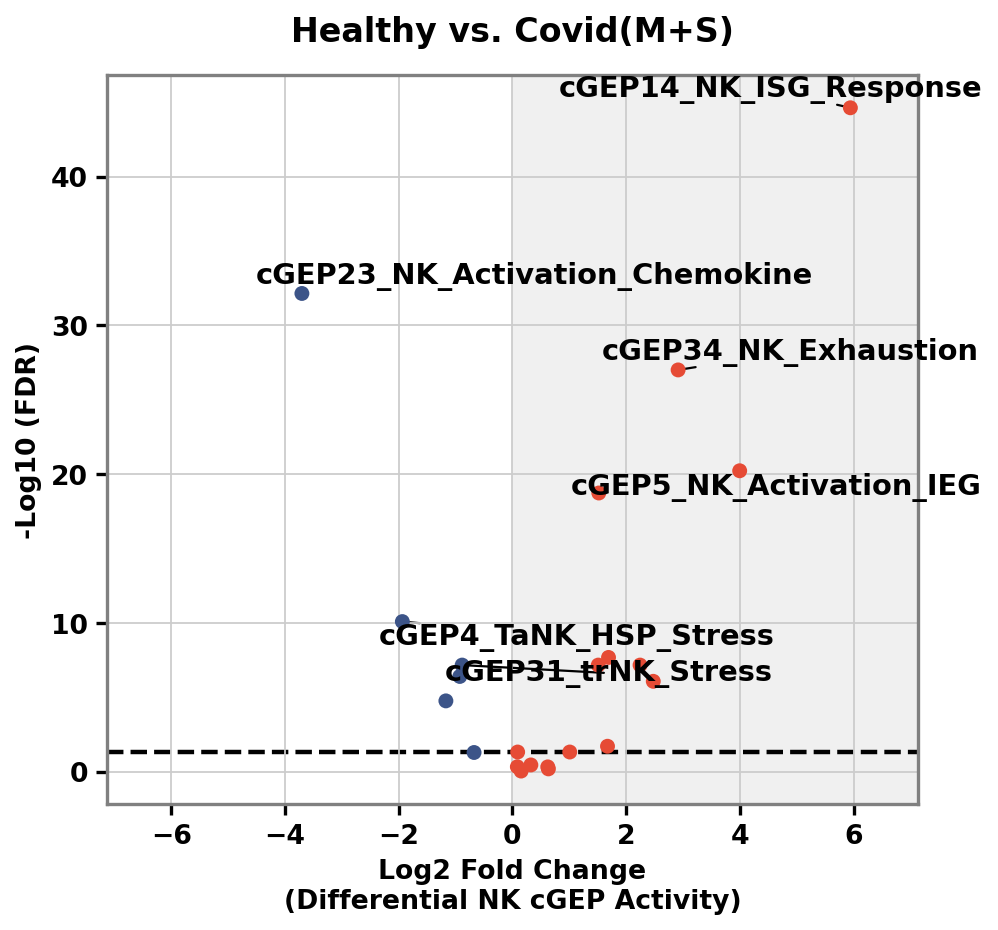

In [26]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# ===========================
# 第一步：准备数据与差异分析
# ===========================

# 1. 提取所有 Usage 列
usage_cols = [c for c in query_adata.obs.columns if c.startswith('Usage:')]
gep_data = query_adata.obs[usage_cols]

# 2. 创建临时 AnnData 对象
gep_adata = sc.AnnData(X=gep_data.values, obs=query_adata.obs)
gep_adata.var_names = usage_cols

# 3. 运行差异分析 (Wilcoxon 秩和检验)
print("正在对比: COVID (M+S) vs Healthy (HC)...")
sc.tl.rank_genes_groups(
    gep_adata, 
    groupby='group2_condition',  # 使用您刚才创建的分组
    groups=['COVID'],            # 实验组：COVID
    reference='Healthy',         # 对照组：Healthy
    method='wilcoxon'
)
# 4. 提取结果表
result = sc.get.rank_genes_groups_df(gep_adata, group='COVID')
df_volcano = result[['names', 'logfoldchanges', 'pvals_adj']].copy()
df_volcano.columns = ['GEP_Name', 'log2FC', 'padj']

# 去除无效值
df_volcano = df_volcano.replace([np.inf, -np.inf], np.nan).dropna()
print("分析完成。前 5 个显著差异 GEP:")
print(df_volcano.head())

# ===========================
# 第二步：绘制高分文献风格火山图
# ===========================

# 1. 设置显著性阈值
pval_th = 0.05
# 参考图只画了横线，因此不再设置强硬的竖线 logFC 阈值，靠左右分布区分

# 2. 定义颜色 (仿照参考图，按正负着色：右侧红色，左侧蓝色)
df_volcano['color'] = np.where(df_volcano['log2FC'] > 0, '#E64B35', '#3C5488') 
df_volcano['alpha'] = 1.0

# 计算 -log10 P值
df_volcano['log_pval'] = -np.log10(df_volcano['padj'] + 1e-300) 

# 3. 开始绘图
fig, ax = plt.subplots(figsize=(6.5, 6)) # 采用接近正方形的比例

# 【关键特征】添加右侧灰色阴影背景
# 获取X轴最大值以确定阴影右边界
x_max = abs(df_volcano['log2FC']).max() * 1.2 
ax.axvspan(0, x_max, facecolor='#f0f0f0', zorder=0)

# 绘制散点
ax.scatter(
    df_volcano['log2FC'], 
    df_volcano['log_pval'], 
    c=df_volcano['color'], 
    s=45, 
    alpha=df_volcano['alpha'], 
    edgecolors='none', 
    zorder=2
)

# 【关键特征】只添加水平黑色粗虚线作为 Q-value/P-value 阈值
ax.axhline(y=-np.log10(pval_th), color='black', linestyle='--', linewidth=2, zorder=1)

# 4. 标注显著的点
texts = []
# 选取 P 值最显著的 top 15 个点进行标注（由于没有中间的垂直线，符合条件的可能较多）
sig_genes = df_volcano[df_volcano['padj'] < pval_th].sort_values('padj')
top_up = df_volcano[(df_volcano['log2FC'] > 0) & (df_volcano['padj'] < pval_th)].sort_values('padj').head(3)
top_dn = df_volcano[(df_volcano['log2FC'] < 0) & (df_volcano['padj'] < pval_th)].sort_values('padj').head(3)

# 合并，变量名为 top_genes
top_genes = pd.concat([top_up, top_dn])

print("\n分析完成。以下是将在火山图上标注的极显著 cGEP：")
print("\n--- 在 COVID 中最显著上调的 Top 5 cGEP (对应图右侧红点) ---")
print(top_up[['GEP_Name', 'log2FC', 'padj', 'log_pval']].to_string(index=False))

print("\n--- 在 COVID 中最显著下调的 Top 5 cGEP (对应图左侧蓝点) ---")
print(top_dn[['GEP_Name', 'log2FC', 'padj', 'log_pval']].to_string(index=False))

for _, row in top_genes.iterrows():
    simple_name = row['GEP_Name'].replace('Usage: ', '')
    # 【全局加粗】添加字体加粗参数 fontweight='bold'
    texts.append(ax.text(row['log2FC'], row['log_pval'], simple_name, 
                         fontsize=13, fontweight='bold', zorder=3))

# 使用 adjust_text 自动避让
try:
    # 【关键特征】连线使用简单的黑色直线，不带箭头
    adjust_text(texts, 
                arrowprops=dict(arrowstyle='-', color='black', lw=1.0),
                ax=ax)
except NameError:
    print("提示: 未安装 adjustText，标签可能会重叠。")

# 5. 装饰图片与【全局加粗】
ax.set_title('Healthy vs. Covid(M+S)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel(f'Log2 Fold Change\n(Differential NK cGEP Activity)', fontsize=12, fontweight='bold') 
ax.set_ylabel('-Log10 (FDR)', fontsize=12, fontweight='bold')

# 加粗刻度文字
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# 加粗坐标轴边框
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('#808080')
ax.tick_params(width=1.5, length=5) # 加粗刻度线本身

# 设置对称的 X 轴范围，使 0 刻度居中，视觉效果更好
ax.set_xlim(-x_max, x_max)

# 保存与展示
import os

output_file = "./5.disease/5.1.COVID/5.1.NK_COVID_Volcano_COVID_Usage-v0420.pdf"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"图片已保存为: {output_file}")
plt.show()